In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import poisson
import scipy

In [56]:
# file = r"C:\Users\Andrew\Documents\Acoustic-Space-Boiling\Data\After_May\MATLAB 2-15 PM Thu, Oct 31, 2024 Run8 .csv"
# file = r"C:\Users\Andrew\Documents\Acoustic-Space-Boiling\Data\After_May\MATLAB 4-29 PM Thu, Oct 10, 2024 Run8 .csv"
# file = r"C:\Users\Andrew\Documents\Acoustic-Space-Boiling\Data\After_May\MATLAB 1-15 PM Thu, Aug 22, 2024 Run5 .csv"
# file = r"C:\Users\Andrew\Documents\Acoustic-Space-Boiling\Data\After_May\MATLAB 12-54 PM Fri, Jun 28, 2024 Run7 .csv"
file = r"C:\Users\Andrew\Documents\Acoustic-Space-Boiling\Data\After_May\MATLAB 12-47 PM Thu, Nov 7, 2024 Run6 .csv"


data = pd.read_csv(file, index_col="Time")
time = data.index

acceleration0 = data['0'] #Using only accelerometer 0

def clamp(value, lower=0.015, upper=0.1):
    return max(lower, min(value, upper))

def get_peaks(acceleration0):
    """
    acceleration0: accelerometer data, measured to the 10,000th of a second
    Returns: x and y coordinates of peaks
    """
    percentile = np.percentile(acceleration0, 99.5)
    percent_of_max = 0.1*np.max(acceleration0)

    height = clamp(max(percentile, percent_of_max))
    distance = 350 + 5 / height

    x, y = scipy.signal.find_peaks(acceleration0, distance=distance, height=height)
    x = x / 10000
    y = y["peak_heights"]  # unpack data
    return x, y

def get_best_gmm_by_bic_jump(peak_amplitudes, n_components_range=range(1, 4), threshold=-50):
    """
    Fits Gaussian Mixture Models (GMM) for different numbers of components and selects the best model 
    based on the largest negative jump in BIC (Bayesian Information Criterion), provided the jump is ≤ threshold.
    
    Parameters:
        peak_amplitudes (numpy array): The data to fit the GMM on.
        n_components_range (range): The range of components to evaluate.
        threshold (float): The minimum BIC decrease required to consider the jump optimal.
    
    Returns:
        best_gmm (GaussianMixture): The best-fitting GMM model.
        best_n_components (int): The optimal number of components.
        bic_list (list): List of computed BIC values.
    """
    best_gmm = None
    best_n_components = 1
    bic_list = []
    gmm_list = []

    # Fit models and store BIC values
    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
        gmm.fit(peak_amplitudes)
        bic = gmm.bic(peak_amplitudes)
        bic_list.append(round(float(bic), 2))
        gmm_list.append(gmm)

    # Compute BIC differences
    bic_diffs = np.diff(bic_list)

    # Determine the best model based on the largest negative jump in BIC (≤ threshold)
    if len(bic_diffs) > 0:
        greatest_decrease_index = np.argmin(bic_diffs)  # Find the largest negative jump
        if bic_diffs[greatest_decrease_index] <= threshold:
            best_n_components = greatest_decrease_index + 2  # Adjust index to component count
            best_gmm = gmm_list[greatest_decrease_index + 1]
        else:
            best_gmm = gmm_list[0]  # Default to 1 component if no significant decrease found

    return best_gmm, best_n_components, bic_list


BIC values: [-95.48, -96.51, -100.1]
Best number of components: 1


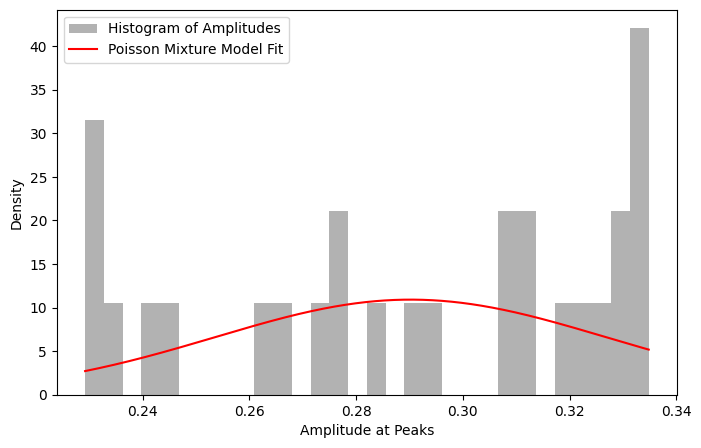

In [57]:
# Extract peak amplitudes
peaks, _ = get_peaks(acceleration0)
peak_amplitudes = acceleration0.loc[peaks].values.reshape(-1, 1)

# Get the best model based on BIC jump
best_gmm, best_n_components, bic_list = get_best_gmm_by_bic_jump(peak_amplitudes)

# Print results
print(f"BIC values: {bic_list}")
print(f"Best number of components: {best_n_components}")

# Visualizing the mixture model
x = np.linspace(min(peak_amplitudes), max(peak_amplitudes), 1000).reshape(-1, 1)
log_prob = best_gmm.score_samples(x)
responsibilities = np.exp(log_prob)

plt.figure(figsize=(8, 5))
plt.hist(peak_amplitudes, bins=30, density=True, alpha=0.6, color='gray', label="Histogram of Amplitudes")
plt.plot(x, responsibilities, label="Poisson Mixture Model Fit", color='red')
plt.xlabel("Amplitude at Peaks")
plt.ylabel("Density")
plt.legend()
plt.show()


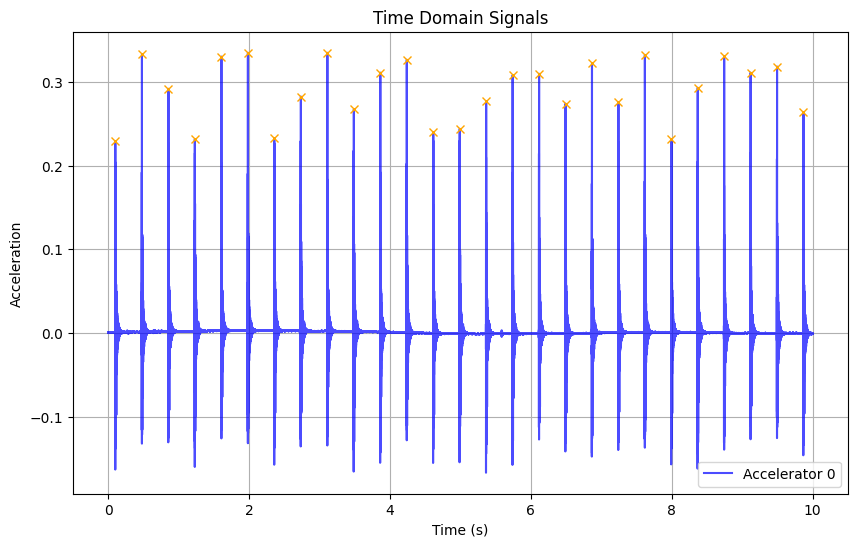

In [58]:
# 2. Plot the time domain signals
plt.figure(figsize=(10, 6))
plt.plot(time, acceleration0, label='Accelerator 0', color='blue', alpha=0.7)
plt.plot(peaks, acceleration0.loc[peaks], "x", color="orange")
plt.title('Time Domain Signals')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration')
plt.legend()
plt.grid(True)
plt.show()

[[0.3779]
 [0.3762]
 [0.3743]
 [0.3776]
 [0.3759]
 [0.3742]
 [0.3775]
 [0.3761]
 [0.3757]
 [0.3757]
 [0.3757]
 [0.3758]
 [0.3756]
 [0.3753]
 [0.3756]
 [0.3757]
 [0.3753]
 [0.3754]
 [0.3753]
 [0.3754]
 [0.3753]
 [0.3749]
 [0.3752]
 [0.3753]
 [0.3754]
 [0.3751]]
BIC values: [-279.96, -270.19, -260.41]
Best number of components: 1
Component 0:
[0.3779 0.3762 0.3743 0.3776 0.3759 0.3742 0.3775 0.3761 0.3757 0.3757
 0.3757 0.3758 0.3756 0.3753 0.3756 0.3757 0.3753 0.3754 0.3753 0.3754
 0.3753 0.3749 0.3752 0.3753 0.3754 0.3751]




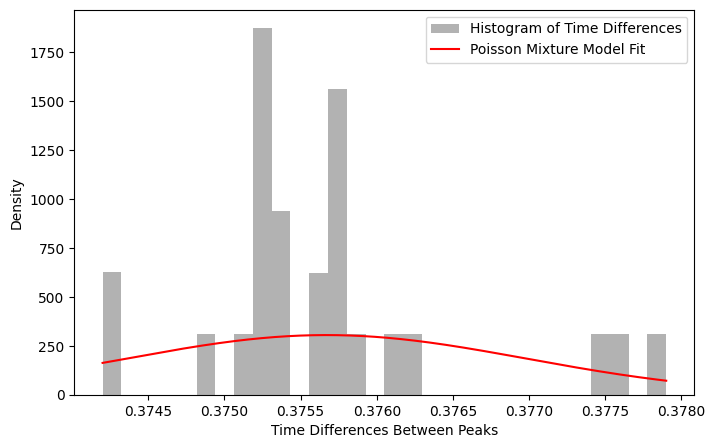

In [59]:
# Get peaks and their time differences
peaks, _ = get_peaks(acceleration0)

# Compute time differences between consecutive peaks
time_differences = np.diff(peaks).reshape(-1, 1) 

print(time_differences)

# Fit GMM to time differences with a max of 3 components
best_gmm, best_n_components, bic_list = get_best_gmm_by_bic_jump(time_differences, n_components_range=range(1, 4))

print(f"BIC values: {bic_list}")
print(f"Best number of components: {best_n_components}")

# Assign each time difference to the most likely component
probabilities = best_gmm.predict_proba(time_differences)
assigned_components = np.argmax(probabilities, axis=1)

# Create DataFrame for visualization
time_components = pd.DataFrame({
    "Time Difference": time_differences.flatten(),
    "Component": assigned_components
})

# Display grouped time differences
for component in range(best_gmm.n_components):
    print(f"Component {component}:")
    print(time_components[time_components["Component"] == component]["Time Difference"].values)
    print("\n")

# Plot histogram and PMM results
x = np.linspace(min(time_differences), max(time_differences), 1000).reshape(-1, 1)
log_prob = best_gmm.score_samples(x)
responsibilities = np.exp(log_prob)

plt.figure(figsize=(8, 5))
plt.hist(time_differences, bins=30, density=True, alpha=0.6, color='gray', label="Histogram of Time Differences")
plt.plot(x, responsibilities, label="Poisson Mixture Model Fit", color='red')
plt.xlabel("Time Differences Between Peaks")
plt.ylabel("Density")
plt.legend()
plt.show()


BIC values: [-2895.7, -2986.06, -3067.87]
Best number of components: 2
Component 0:
[2.38767147e-03 3.58214974e-03 3.81037927e-02 1.05909550e-02
 1.47404659e-02 4.75658083e-02 4.47611296e-02 4.65390325e-02
 2.15121746e-03 3.42100120e-02 4.10684633e-02 2.60613441e-03
 2.01178670e-03 1.95652843e-03 2.17794704e-02 6.35341644e-03
 2.48366666e-02 2.31210899e-02 1.07984948e-02 5.71216345e-04
 3.98508537e-02 2.01435685e-03 2.18276608e-02 1.44873059e-02
 4.10684633e-02 3.84623289e-02 4.30802500e-02 9.27567959e-03
 4.30249918e-02 2.44492161e-02 1.92889929e-02 3.47150469e-02
 4.78125429e-02 1.49872005e-02 1.62317967e-02 1.79473734e-02
 1.77918792e-02 3.02699685e-02 1.60139763e-02 4.04972470e-02
 1.21760964e-03 3.90541065e-02 1.92408025e-02 2.65811574e-02
 2.83429968e-02 2.38767147e-03 1.19447827e-03 3.57161212e-02
 8.20328355e-03 1.23527944e-02 4.51781368e-02 4.23734581e-02
 4.41513610e-02 2.36454010e-04 3.18223405e-02 2.60613441e-03
 3.84623289e-02 4.61792111e-03 4.77380085e-02 4.56266284e-03
 

C:\Users\Andrew\AppData\Local\Temp\ipykernel_21076\706085783.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  peak_diffs[i, j] = abs(peak_amplitudes[i] - peak_amplitudes[j])


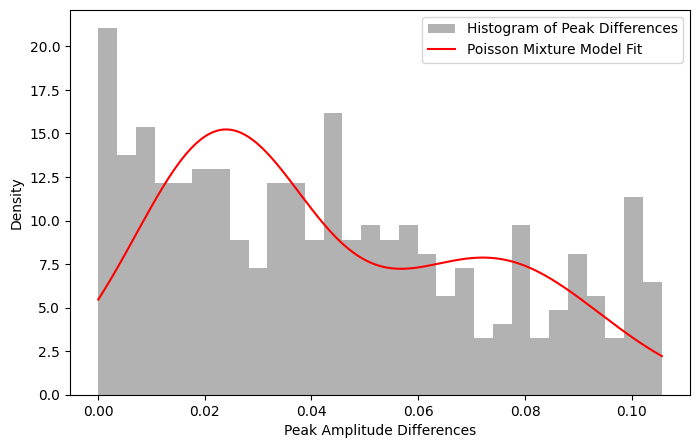

In [61]:
# Compute all pairwise peak amplitude differences using nested loops
peak_diffs = np.zeros((len(peak_amplitudes), len(peak_amplitudes)))

for i in range(len(peak_amplitudes)):
    for j in range(len(peak_amplitudes)):
        if i != j:
            peak_diffs[i, j] = abs(peak_amplitudes[i] - peak_amplitudes[j])

# Flatten to a 1D array and remove zero differences (self-comparisons)
peak_diffs = peak_diffs.flatten()
peak_diffs = peak_diffs[peak_diffs > 0]
peak_diffs = peak_diffs.reshape(-1, 1)  # Reshape for GMM input

# Function to fit Gaussian Mixture Model
def get_best_gmm_by_bic_jump(peak_diffs, n_components_range=range(1, 4), threshold=-50):
    best_gmm = None
    best_n_components = 1
    bic_list = []
    gmm_list = []

    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
        gmm.fit(peak_diffs)
        bic = gmm.bic(peak_diffs)
        bic_list.append(round(float(bic), 2))
        gmm_list.append(gmm)

    bic_diffs = np.diff(bic_list)
    
    if len(bic_diffs) > 0:
        greatest_decrease_index = np.argmin(bic_diffs)
        if bic_diffs[greatest_decrease_index] <= threshold:
            best_n_components = greatest_decrease_index + 2
            best_gmm = gmm_list[greatest_decrease_index + 1]
        else:
            best_gmm = gmm_list[0]

    return best_gmm, best_n_components, bic_list

# Fit GMM to peak amplitude differences
best_gmm, best_n_components, bic_list = get_best_gmm_by_bic_jump(peak_diffs)

print(f"BIC values: {bic_list}")
print(f"Best number of components: {best_n_components}")

# Assign each peak difference to the most likely component
probabilities = best_gmm.predict_proba(peak_diffs)
assigned_components = np.argmax(probabilities, axis=1)

# Create DataFrame to visualize results
peak_diff_components = pd.DataFrame({
    "Peak Difference": peak_diffs.flatten(),
    "Component": assigned_components
})

# Display grouped peak differences
for component in range(best_gmm.n_components):
    print(f"Component {component}:")
    print(peak_diff_components[peak_diff_components["Component"] == component]["Peak Difference"].values)
    print("\n")

# Plot histogram and PMM results
x = np.linspace(min(peak_diffs), max(peak_diffs), 1000).reshape(-1, 1)
log_prob = best_gmm.score_samples(x)
responsibilities = np.exp(log_prob)

plt.figure(figsize=(8, 5))
plt.hist(peak_diffs, bins=30, density=True, alpha=0.6, color='gray', label="Histogram of Peak Differences")
plt.plot(x, responsibilities, label="Poisson Mixture Model Fit", color='red')
plt.xlabel("Peak Amplitude Differences")
plt.ylabel("Density")
plt.legend()
plt.show()